In [14]:
import pandas as pd
import numpy as np

from sklearn.metrics import precision_recall_fscore_support
from datetime import datetime

# Ruta del dataset final (ajustá si hace falta)
CSV_PATH = "monthly_master.csv"

df = pd.read_csv(CSV_PATH)

# Tipos básicos
df["store_id"] = df["store_id"].astype(str)
df["period_month"] = df["period_month"].astype(str)
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")


In [15]:
# Filtramos por CABA (ajustá si tu columna trae espacios o minúsculas)
df = df[df["ciudad"].astype(str).str.upper().eq("CABA")].copy()

# Probá con/sin este filtro según lo que definieron en el grupo
USE_ONLY_2025 = True
if USE_ONLY_2025:
    df = df[df["period_month"] >= "2025-01"].copy()

df.shape


(39538, 32)

In [16]:
# Target binario mensual (etiqueta real)
df["is_churn"] = (df["stage"].astype(str).str.lower() == "churn").astype(int)

# Conectividad mensual a partir de minutos (si hay columnas; sino quedan NaN)
for col in ["total_min_open", "total_minutes_all"]:
    if col not in df.columns:
        df[col] = np.nan
df["connectivity"] = df["total_min_open"] / df["total_minutes_all"]

# Señales de actividad (aseguramos existencia)
for c in ["tpn", "gmv", "days_with_orders"]:
    if c not in df.columns:
        df[c] = 0.0

# Helper: YYYY-MM -> Timestamp primer día del mes (Prophet usa 'ds')
def month_to_ts(ym: str) -> pd.Timestamp:
    return pd.Period(ym, freq="M").to_timestamp()

df["ds"] = df["period_month"].apply(month_to_ts)

df[["store_id","period_month","stage","is_churn","tpn","connectivity"]].head()


,store_id,period_month,stage,is_churn,tpn,connectivity
23,100006,2025-01,Retained,0,10.0,NaN
24,100006,2025-02,Retained,0,10.0,NaN
25,100006,2025-03,Retained,0,2.0,NaN
26,100006,2025-04,Retained,0,2.0,NaN
27,100006,2025-05,Retained,0,6.0,NaN


In [17]:
# Usamos un walk-forward: entreno hasta t-1, predigo t
all_months = sorted(df["period_month"].unique())
if len(all_months) < 3:
    raise ValueError("Hay muy pocos meses en la ventana seleccionada. Probá ampliar el rango temporal.")

# Evaluamos desde el segundo mes disponible
eval_months = all_months[1:]
eval_months


['2025-02',
 '2025-03',
 '2025-04',
 '2025-05',
 '2025-06',
 '2025-07',
 '2025-08',
 '2025-09']

In [18]:
# === BLOQUE 5R v2 — Modelo rápido con pseudo-tendencia ===
signal_col = "tpn"

df_fast = df.sort_values(["store_id","ds"]).copy()

# Media móvil de 3 meses y pequeña tendencia
def moving_trend(x):
    ma3 = x.shift(1).rolling(3, min_periods=1).mean()
    trend = x.shift(1) - x.shift(2)         # diferencia mes a mes
    pred = ma3 + 0.3 * trend.fillna(0)       # agrega parte de la pendiente
    return pred

df_fast["tpn_pred"] = (
    df_fast.groupby("store_id")[signal_col]
           .apply(moving_trend)
           .reset_index(level=0, drop=True)
)

pred_df = (
    df_fast.loc[df_fast["period_month"].isin(eval_months),
                ["store_id","period_month","tpn_pred","is_churn"]]
      .rename(columns={"is_churn":"y_true","tpn_pred":"yhat_tpn"})
      .copy()
)

pred_df.head()




,store_id,period_month,yhat_tpn,y_true
24,100006,2025-02,10.000000,0
25,100006,2025-03,10.000000,0
26,100006,2025-04,4.933333,0
27,100006,2025-05,4.666667,0
28,100006,2025-06,4.533333,0


In [13]:
print(pred_df["yhat_tpn"].describe())
print(pred_df["yhat_tpn"].value_counts().head(10))


count    34223.000000
mean        78.219287
std        351.300585
min          0.000000
25%          0.000000
50%          0.666667
75%         30.000000
max       9354.000000
Name: yhat_tpn, dtype: float64
yhat_tpn
0.000000     16682
2.000000       728
0.666667       613
4.000000       480
1.333333       372
6.000000       368
8.000000       306
2.666667       280
10.000000      278
12.000000      250
Name: count, dtype: int64


In [19]:
# === BLOQUE 6 — Calibración adaptada para skewed yhat_tpn ===
from sklearn.metrics import precision_score, recall_score, f1_score

# Definir umbral operativo: por percentil 30 o mínimo 5 pedidos
low_quantile = pred_df["yhat_tpn"].quantile(0.30)
tpn_threshold = max(low_quantile, 5)
print(f"Nuevo umbral de TPN para marcar churn: {tpn_threshold:.2f}")

# Clasificación
pred_df["y_pred"] = (pred_df["yhat_tpn"] <= tpn_threshold).astype(int)

# Métricas globales
precision = precision_score(pred_df["y_true"], pred_df["y_pred"], zero_division=0)
recall    = recall_score(pred_df["y_true"], pred_df["y_pred"], zero_division=0)
f1        = f1_score(pred_df["y_true"], pred_df["y_pred"], zero_division=0)
print(f"[Global] Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}")

# Métricas por mes
metrics_by_month = (
    pred_df.groupby("period_month", sort=True)
           .apply(lambda x: pd.Series({
               "precision": precision_score(x["y_true"], x["y_pred"], zero_division=0),
               "recall":    recall_score(x["y_true"], x["y_pred"], zero_division=0),
               "f1":        f1_score(x["y_true"], x["y_pred"], zero_division=0)
           }), include_groups=False)
           .reset_index()
)

metrics_by_month



Nuevo umbral de TPN para marcar churn: 5.00
[Global] Precision=0.035 | Recall=0.479 | F1=0.065


,period_month,precision,recall,f1
0,2025-02,0.034271,0.536000,0.064423
1,2025-03,0.035798,0.584615,0.067466
2,2025-04,0.037963,0.562914,0.071130
3,2025-05,0.036154,0.543210,0.067797
4,2025-06,0.026377,0.417178,0.049617
5,2025-07,0.031822,0.475410,0.059650
6,2025-08,0.027893,0.445055,0.052495
7,2025-09,0.048128,0.402235,0.085970


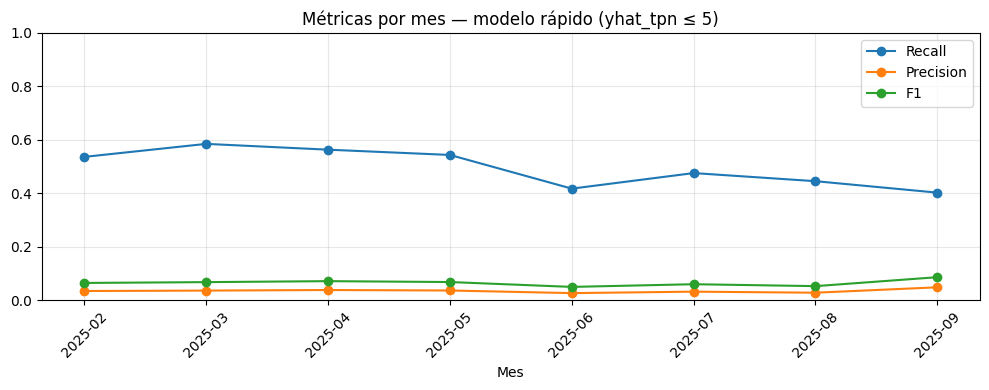

In [22]:
import matplotlib.pyplot as plt

mplot = metrics_by_month.sort_values("period_month")

plt.figure(figsize=(10,4))
plt.plot(mplot["period_month"], mplot["recall"], marker="o", label="Recall")
plt.plot(mplot["period_month"], mplot["precision"], marker="o", label="Precision")
plt.plot(mplot["period_month"], mplot["f1"], marker="o", label="F1")
plt.title("Métricas por mes — modelo rápido (yhat_tpn ≤ 5)")
plt.xlabel("Mes")
plt.ylim(0, 1)
plt.grid(True, alpha=.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Grid de umbrales candidate
candidates = sorted(set(list(np.linspace(1, 15, 15)) + [5, 10, 20, 30]))

rows = []
for thr in candidates:
    y_pred = (pred_df["yhat_tpn"] <= thr).astype(int)
    p = precision_score(pred_df["y_true"], y_pred, zero_division=0)
    r = recall_score(pred_df["y_true"], y_pred, zero_division=0)
    f = f1_score(pred_df["y_true"], y_pred, zero_division=0)
    rows.append({"threshold": thr, "precision": p, "recall": r, "f1": f})

thr_table = pd.DataFrame(rows).sort_values(["recall","f1"], ascending=[False, False])
thr_table.reset_index(drop=True, inplace=True)
thr_table.head(10)



,threshold,precision,recall,f1
0,30.0,0.051016,0.898212,0.096548
1,20.0,0.051024,0.843191,0.096225
2,15.0,0.050037,0.792297,0.094129
3,14.0,0.049845,0.782669,0.093720
4,13.0,0.049071,0.761348,0.092200
5,12.0,0.048082,0.737964,0.090282
6,11.0,0.046614,0.704952,0.087446
7,10.0,0.046083,0.689821,0.086395
8,9.0,0.044671,0.657497,0.083658
9,8.0,0.043486,0.633425,0.081386


In [27]:
# Elegí automáticamente el primer umbral que logra recall ≥ 0.55 (ajustá el target)
recall_target = 0.55
chosen = thr_table.loc[thr_table["recall"] >= recall_target].head(1)
if chosen.empty:
    chosen = thr_table.head(1)  # si ninguno llega, tomamos el mejor
chosen_threshold = float(chosen["threshold"].iloc[0])
chosen


,threshold,precision,recall,f1
0,30.0,0.051016,0.898212,0.096548


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

pred_df["y_pred"] = (pred_df["yhat_tpn"] <= chosen_threshold).astype(int)

p = precision_score(pred_df["y_true"], pred_df["y_pred"], zero_division=0)
r = recall_score(pred_df["y_true"], pred_df["y_pred"], zero_division=0)
f = f1_score(pred_df["y_true"], pred_df["y_pred"], zero_division=0)
print(f"[GLOBAL con threshold={chosen_threshold}] Precision={p:.3f} | Recall={r:.3f} | F1={f:.3f}")

metrics_by_month = (
    pred_df.groupby("period_month", sort=True)
           .apply(lambda x: pd.Series({
               "precision": precision_score(x["y_true"], x["y_pred"], zero_division=0),
               "recall":    recall_score(x["y_true"], x["y_pred"], zero_division=0),
               "f1":        f1_score(x["y_true"], x["y_pred"], zero_division=0)
           }), include_groups=False)
           .reset_index()
)
metrics_by_month


[GLOBAL con threshold=30.0] Precision=0.051 | Recall=0.898 | F1=0.097


,period_month,precision,recall,f1
0,2025-02,0.048580,0.944000,0.092404
1,2025-03,0.045234,0.930769,0.086275
2,2025-04,0.049895,0.947020,0.094796
3,2025-05,0.046203,0.901235,0.087899
4,2025-06,0.044056,0.895706,0.083980
5,2025-07,0.046485,0.896175,0.088386
6,2025-08,0.040876,0.840659,0.077962
7,2025-09,0.081081,0.879888,0.148480


In [24]:
# Adjuntamos segmento a las predicciones
seg_map = df[["store_id","segmento"]].drop_duplicates()
pred_seg = pred_df.merge(seg_map, on="store_id", how="left")

# elegimos umbral por segmento para máximo recall con precisión mínima
segments = pred_seg["segmento"].dropna().unique()
res = []

min_precision = 0.03     # asegurá al menos 3% de precisión global por segmento
candidates = list(np.linspace(1, 15, 15)) + [20, 30]

best_thr = {}

for seg in segments:
    sub = pred_seg[pred_seg["segmento"] == seg]
    if sub.empty:
        continue
    best = None
    for thr in candidates:
        y_pred = (sub["yhat_tpn"] <= thr).astype(int)
        p = precision_score(sub["y_true"], y_pred, zero_division=0)
        r = recall_score(sub["y_true"], y_pred, zero_division=0)
        f = f1_score(sub["y_true"], y_pred, zero_division=0)
        if best is None or (r > best["recall"] and p >= min_precision):
            best = {"segmento": seg, "threshold": thr, "precision": p, "recall": r, "f1": f}
    if best is None:
        # si no cumple min_precision, tomamos el máximo recall igual
        tmp = []
        for thr in candidates:
            y_pred = (sub["yhat_tpn"] <= thr).astype(int)
            p = precision_score(sub["y_true"], y_pred, zero_division=0)
            r = recall_score(sub["y_true"], y_pred, zero_division=0)
            f = f1_score(sub["y_true"], y_pred, zero_division=0)
            tmp.append({"segmento": seg, "threshold": thr, "precision": p, "recall": r, "f1": f})
        best = sorted(tmp, key=lambda d: (d["recall"], d["f1"]), reverse=True)[0]
    best_thr[seg] = best["threshold"]
    res.append(best)

seg_thresholds = pd.DataFrame(res).sort_values("segmento")
seg_thresholds



,segmento,threshold,precision,recall,f1
0,Microstores,30.0,0.053480,0.923394,0.101105
2,Picked Locals,30.0,0.047151,0.776536,0.088903
1,Top Players,15.0,0.030574,0.672131,0.058488


In [26]:
from sklearn.metrics import confusion_matrix

cms = []
for ym, sub in pred_df.groupby("period_month"):
    y_t = sub["y_true"].fillna(0).astype(int)
    y_p = sub["y_pred"].fillna(0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0,1]).ravel()
    cms.append({"period_month": ym, "TN": tn, "FP": fp, "FN": fn, "TP": tp})

cm_df = pd.DataFrame(cms).sort_values("period_month")
cm_df



,period_month,TN,FP,FN,TP
0,2025-02,1507,1888,58,67
1,2025-03,1651,2047,54,76
2,2025-04,1836,2154,66,85
3,2025-05,1959,2346,74,88
4,2025-06,2051,2510,95,68
5,2025-07,2263,2647,96,87
6,2025-08,2288,2823,101,81
7,2025-09,2109,2848,214,144
